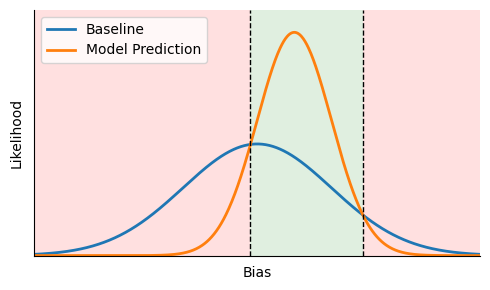

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu1, sigma1 = 0.0, 1.0          # wide distribution
mu2, sigma2 = 0.5, 0.5         # narrow, slightly shifted

def normal_pdf(x, mu, sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

# Solve for intersections analytically
a = 1/(2*sigma1**2) - 1/(2*sigma2**2)
b = mu2/(sigma2**2) - mu1/(sigma1**2)
c = (mu1**2)/(2*sigma1**2) - (mu2**2)/(2*sigma2**2) - np.log(sigma2/sigma1)

roots = np.roots([a, b, c])
x_int = np.sort(roots.real)

# Plot
x = np.linspace(-4, 4, 1000)
y1 = normal_pdf(x, mu1, sigma1)
y2 = normal_pdf(x, mu2, sigma2)

fig, ax = plt.subplots(figsize=(5, 3))

# Shade regions: red where baseline is more likely, green where model is
ax.axvspan(-4, x_int[0], color='red', alpha=0.12, lw=0, zorder=0)
ax.axvspan(x_int[1], 4, color='red', alpha=0.12, lw=0, zorder=0)
ax.axvspan(x_int[0], x_int[1], color='green', alpha=0.12, lw=0, zorder=0)

ax.plot(x, y1, lw=2, label = 'Baseline')
ax.plot(x, y2, lw=2, label = 'Model Prediction')

for xi in x_int:
    ax.axvline(xi, ls='--', lw=1, color = 'k')

# Minimalist infographic style
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-3, 3)
ax.set_ylim(0, max(y1.max(), y2.max())*1.1)
ax.spines[['top','right']].set_visible(False)
plt.ylabel('Likelihood')
plt.xlabel('Bias')
plt.legend()

plt.tight_layout()
plt.savefig("figs/pdf_infographic.pdf")
plt.show()